Dataset Shape: (10000, 12)

First Five Records


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Summary Statistics


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,1.19940,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,0.60023,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,0.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1.00000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,1.00000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,2.00000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,2.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


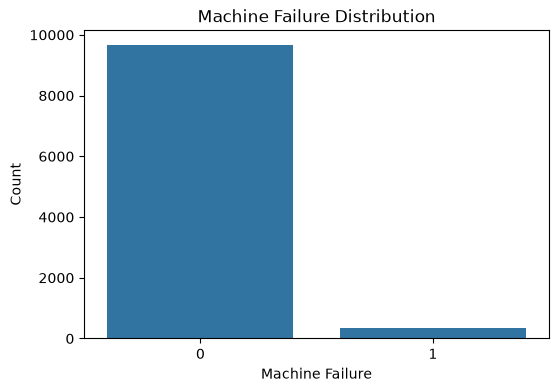

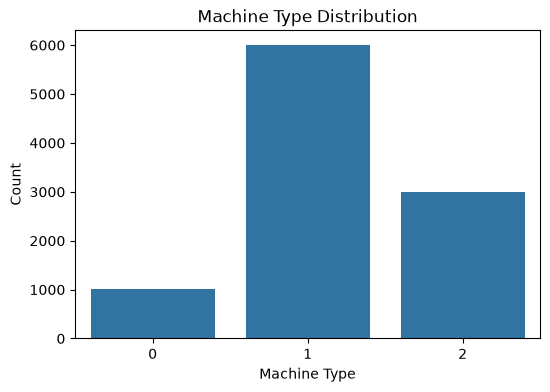

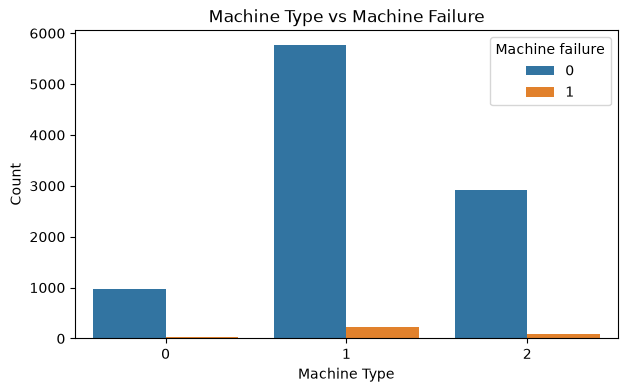

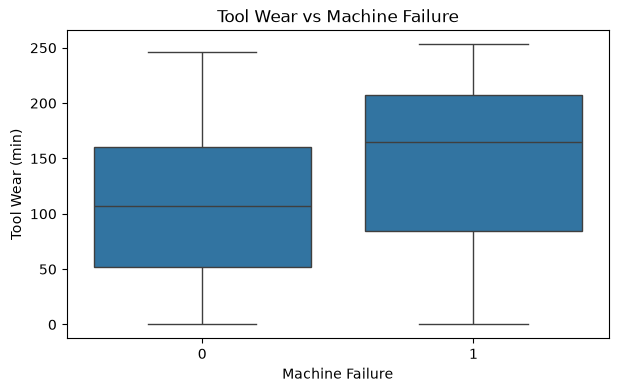

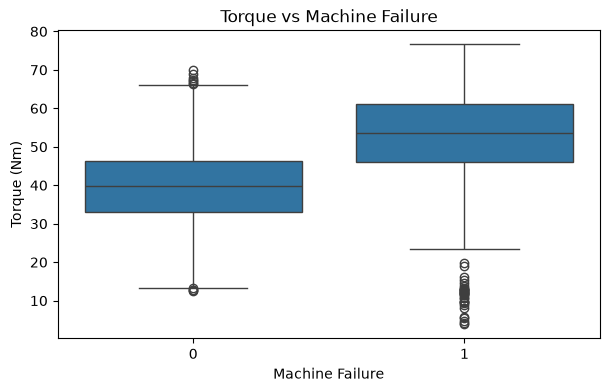

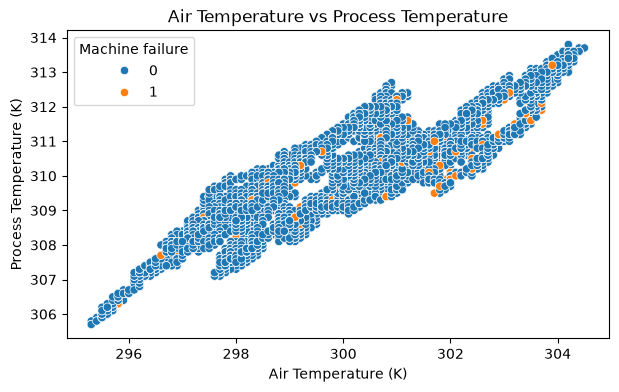

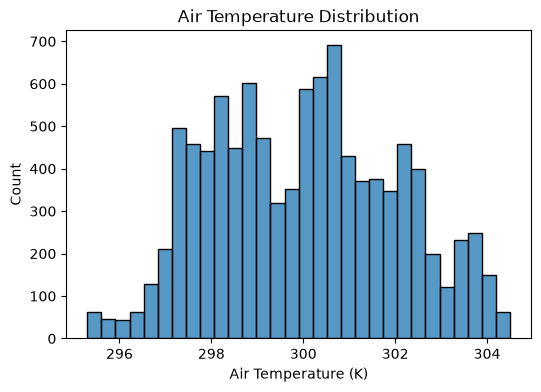

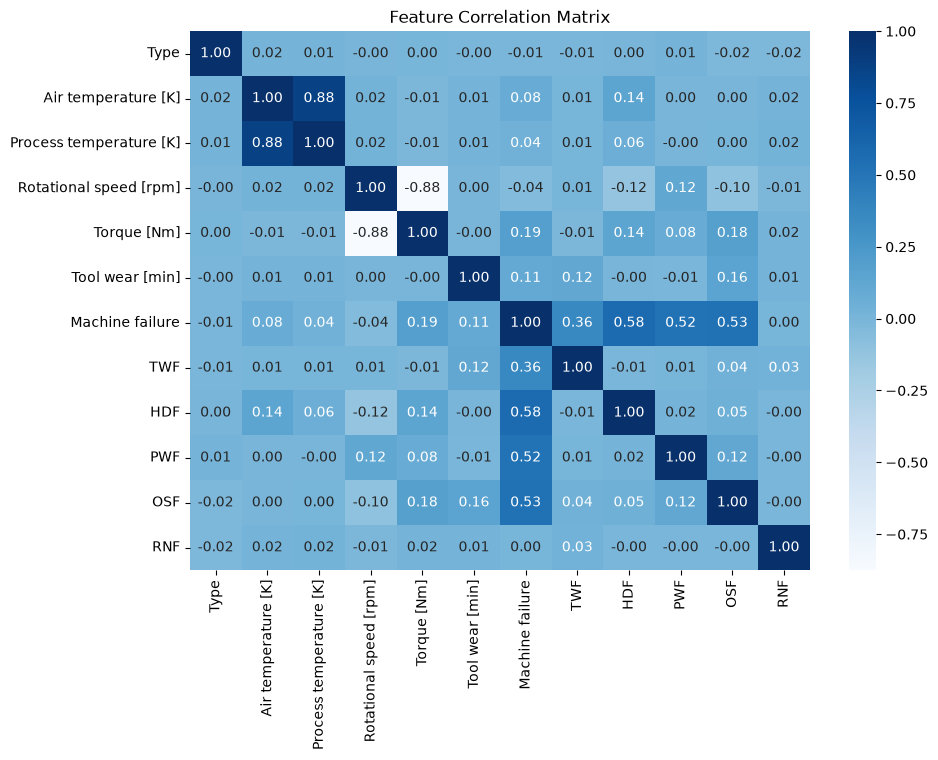

Current Working Directory:
d:\Industrial-Equipment-Reliability-Intelligence-Platform\03_Notebooks

Does 06_Images exist?
True


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("../02_Data/Raw/ai4i2020.csv")

# Basic preprocessing
df.drop(columns=["UDI", "Product ID"], inplace=True)

encoder = LabelEncoder()
df["Type"] = encoder.fit_transform(df["Type"])

# Dataset overview
print("Dataset Shape:", df.shape)

print("\nFirst Five Records")
display(df.head())

print("\nSummary Statistics")
display(df.describe())


# Machine failure distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Machine failure", data=df)
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.savefig(
    "../06_Images/machine_failure_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Machine type distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Type", data=df)
plt.title("Machine Type Distribution")
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.show()


# Machine type vs failure
plt.figure(figsize=(7, 4))
sns.countplot(x="Type", hue="Machine failure", data=df)
plt.title("Machine Type vs Machine Failure")
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.show()


# Tool wear vs failure
plt.figure(figsize=(7, 4))
sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df)
plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear (min)")
plt.show()


# Torque vs failure
plt.figure(figsize=(7, 4))
sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df)
plt.title("Torque vs Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Torque (Nm)")
plt.show()


# Temperature relationship
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Machine failure"
)
plt.title("Air Temperature vs Process Temperature")
plt.xlabel("Air Temperature (K)")
plt.ylabel("Process Temperature (K)")
plt.show()


# Air temperature distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["Air temperature [K]"], bins=30)
plt.title("Air Temperature Distribution")
plt.xlabel("Air Temperature (K)")
plt.show()


# Correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("Feature Correlation Matrix")

plt.savefig(
    "../06_Images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Industrial Equipment Reliability Intelligence Platform

## Exploratory Data Analysis (EDA)

This notebook explores the processed dataset to understand feature distributions, identify relationships, detect outliers, and discover patterns related to machine failure.